In [8]:
import math
import random
import time
import os
import csv

# --- 1. НАСТРОЙКА ПУТИ ---
DIRECTORY_PATH = "/E"

# --- 2. КЛАСС ДАННЫХ ---
class VRPInstance:
    def __init__(self):
        self.name = ""
        self.dimension = 0
        self.capacity = 0
        self.coords = {}
        self.demands = {}
        self.depot_id = 1

    def load_from_file(self, filename):
        with open(filename, 'r') as f:
            section = None
            for line in f:
                line = line.strip()
                if not line: continue
                if line.startswith("NAME"): self.name = line.split(":")[1].strip()
                elif line.startswith("DIMENSION"): self.dimension = int(line.split(":")[1].strip())
                elif line.startswith("CAPACITY"): self.capacity = int(line.split(":")[1].strip())
                elif line.startswith("NODE_COORD_SECTION"): section = "COORDS"
                elif line.startswith("DEMAND_SECTION"): section = "DEMANDS"
                elif line.startswith("DEPOT_SECTION"): section = "DEPOT"
                elif line == "EOF": break
                else:
                    if section == "COORDS":
                        parts = line.split()
                        self.coords[int(parts[0])] = (float(parts[1]), float(parts[2]))
                    elif section == "DEMANDS":
                        parts = line.split()
                        self.demands[int(parts[0])] = int(parts[1])
                    elif section == "DEPOT":
                        if int(line) != -1: self.depot_id = int(line)

    def dist(self, i, j):
        x1, y1 = self.coords[i]
        x2, y2 = self.coords[j]
        return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# --- 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ---
def route_cost(route, instance):
    if not route: return 0
    cost = instance.dist(instance.depot_id, route[0])
    for i in range(len(route) - 1):
        cost += instance.dist(route[i], route[i+1])
    cost += instance.dist(route[-1], instance.depot_id)
    return cost

def total_cost(solution, instance):
    return sum(route_cost(r, instance) for r in solution)

def greedy_initial_solution(instance):
    remaining = list(range(1, instance.dimension + 1))
    remaining.remove(instance.depot_id)
    routes = []
    while remaining:
        route = []
        load = 0
        last = instance.depot_id
        changed = True
        while changed:
            changed = False
            best = None
            min_d = float('inf')
            for c in remaining:
                if load + instance.demands[c] <= instance.capacity:
                    d = instance.dist(last, c)
                    if d < min_d:
                        min_d = d
                        best = c
            if best is not None:
                route.append(best)
                remaining.remove(best)
                load += instance.demands[best]
                last = best
                changed = True
        if route: routes.append(route)
    return routes

def get_optimal_cost(sol_filename):
    if not os.path.exists(sol_filename): return None
    try:
        with open(sol_filename, 'r') as f:
            for line in f:
                if line.startswith("Cost"):
                    return float(line.split()[1])
    except: return None
    return None

# --- 4. АЛГОРИТМ (ОДНА ПРАВИЛЬНАЯ ФУНКЦИЯ) ---
def solve_vrp_sa(instance):
    # Параметры для хорошего качества (баланс время/точность)
    T0 = 2000.0
    T_end = 0.01      # Охлаждаем до минимума
    alpha = 0.998     # Медленное охлаждение
    iter_per_T = 100  # Много итераций на шаг

    current_sol = greedy_initial_solution(instance)
    current_cost = total_cost(current_sol, instance)
    best_sol, best_cost = [list(r) for r in current_sol], current_cost
    T = T0

    while T > T_end:
        for _ in range(iter_per_T):
            # Используем 3 оператора для лучшего поиска
            op = random.choice(['2opt', 'relocate', 'exchange'])

            if op == '2opt' and current_sol:
                # Оператор 2-opt (разворот участка)
                r_idx = random.randint(0, len(current_sol) - 1)
                route = current_sol[r_idx]
                if len(route) >= 2:
                    i, j = sorted(random.sample(range(len(route)), 2))

                    # Быстрый расчет дельты
                    n_prev = instance.depot_id if i == 0 else route[i-1]
                    n_i = route[i]
                    n_j = route[j]
                    n_next = instance.depot_id if j == len(route)-1 else route[j+1]

                    delta = (instance.dist(n_prev, n_j) + instance.dist(n_i, n_next)) - \
                            (instance.dist(n_prev, n_i) + instance.dist(n_j, n_next))

                    if delta < 0 or random.random() < math.exp(-delta / T):
                        route[i:j+1] = reversed(route[i:j+1])
                        current_cost += delta
                        if current_cost < best_cost:
                            best_cost = current_cost
                            best_sol = [list(r) for r in current_sol]

            elif op == 'relocate' and len(current_sol) >= 2:
                # Оператор Relocate (перенос клиента)
                r1, r2 = random.sample(range(len(current_sol)), 2)
                if current_sol[r1]:
                    old_cost_r1 = route_cost(current_sol[r1], instance)
                    old_cost_r2 = route_cost(current_sol[r2], instance)

                    idx = random.randint(0, len(current_sol[r1]) - 1)
                    customer = current_sol[r1][idx]

                    # Проверка вместимости
                    if sum(instance.demands[c] for c in current_sol[r2]) + instance.demands[customer] <= instance.capacity:
                        # Переносим
                        cust = current_sol[r1].pop(idx)
                        ins_idx = random.randint(0, len(current_sol[r2]))
                        current_sol[r2].insert(ins_idx, cust)

                        new_cost_r1 = route_cost(current_sol[r1], instance)
                        new_cost_r2 = route_cost(current_sol[r2], instance)

                        delta = (new_cost_r1 + new_cost_r2) - (old_cost_r1 + old_cost_r2)

                        if delta < 0 or random.random() < math.exp(-delta / T):
                            current_cost += delta
                            if current_cost < best_cost:
                                best_cost = current_cost
                                best_sol = [list(r) for r in current_sol]
                        else:
                            # Откат
                            current_sol[r2].pop(ins_idx)
                            current_sol[r1].insert(idx, cust)

            elif op == 'exchange' and len(current_sol) >= 2:
                # Оператор Exchange (обмен клиентами между маршрутами)
                r1, r2 = random.sample(range(len(current_sol)), 2)
                if current_sol[r1] and current_sol[r2]:
                    old_c1 = route_cost(current_sol[r1], instance)
                    old_c2 = route_cost(current_sol[r2], instance)

                    idx1 = random.randint(0, len(current_sol[r1]) - 1)
                    idx2 = random.randint(0, len(current_sol[r2]) - 1)

                    c1 = current_sol[r1][idx1]
                    c2 = current_sol[r2][idx2]

                    # Проверка вместимости
                    load1 = sum(instance.demands[c] for c in current_sol[r1]) - instance.demands[c1] + instance.demands[c2]
                    load2 = sum(instance.demands[c] for c in current_sol[r2]) - instance.demands[c2] + instance.demands[c1]

                    if load1 <= instance.capacity and load2 <= instance.capacity:
                        # Обмен
                        current_sol[r1][idx1] = c2
                        current_sol[r2][idx2] = c1

                        new_c1 = route_cost(current_sol[r1], instance)
                        new_c2 = route_cost(current_sol[r2], instance)

                        delta = (new_c1 + new_c2) - (old_c1 + old_c2)

                        if delta < 0 or random.random() < math.exp(-delta / T):
                            current_cost += delta
                            if current_cost < best_cost:
                                best_cost = current_cost
                                best_sol = [list(r) for r in current_sol]
                        else:
                            # Откат обмена
                            current_sol[r1][idx1] = c1
                            current_sol[r2][idx2] = c2

        T *= alpha

    return best_sol, best_cost

# --- 5. ЗАПУСК ОБРАБОТКИ ---
def run_batch_processing(directory_path):
    files = sorted([f for f in os.listdir(directory_path) if f.endswith('.vrp')])
    if not files:
        print(f"ОШИБКА: В папке {directory_path} нет файлов .vrp!")
        return

    csv_filename = os.path.join(directory_path, "results_summary.csv")

    print(f"Найдено {len(files)} задач. Режим: Качественный (около 10-15 сек на файл)")
    print(f"{'File':<20} | {'My Cost':<10} | {'Optimal':<10} | {'Dev %':<8} | {'Time':<8}")
    print("-" * 65)

    with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['File', 'My Cost', 'Optimal', 'Deviation %', 'Time (s)'])

        for filename in files:
            full_path_vrp = os.path.join(directory_path, filename)
            full_path_sol = full_path_vrp.replace('.vrp', '.sol')

            try:
                instance = VRPInstance()
                instance.load_from_file(full_path_vrp)

                start_t = time.time()
                sol, cost = solve_vrp_sa(instance) # Вызываем правильную функцию
                elapsed = time.time() - start_t

                opt_cost = get_optimal_cost(full_path_sol)
                dev = ((cost - opt_cost) / opt_cost) * 100 if opt_cost else 0

                status = "OK" if dev <= 10 else "BAD"
                print(f"{filename:<20} | {cost:<10.2f} | {opt_cost:<10} | {dev:<8.2f} | {elapsed:.2f}s {status}")

                writer.writerow([filename, round(cost, 2), opt_cost, round(dev, 2), round(elapsed, 2)])
            except Exception as e:
                print(f"Ошибка в {filename}: {e}")



Найдено 13 задач. Режим: Качественный (около 10-15 сек на файл)
File                 | My Cost    | Optimal    | Dev %    | Time    
-----------------------------------------------------------------
E-n101-k14.vrp       | 1188.83    | 1067.0     | 11.42    | 7.68s ⚠️ BAD
E-n101-k8.vrp        | 948.25     | 815.0      | 16.35    | 11.48s ⚠️ BAD
Ошибка в E-n13-k4.vrp: 1
E-n22-k4.vrp         | 383.65     | 375.0      | 2.31     | 7.01s ✅ OK
E-n23-k3.vrp         | 568.56     | 569.0      | -0.08    | 8.42s ✅ OK
E-n30-k3.vrp         | 552.45     | 534.0      | 3.46     | 10.25s ✅ OK
Ошибка в E-n31-k7.vrp: 1
E-n33-k4.vrp         | 837.67     | 835.0      | 0.32     | 8.80s ✅ OK
E-n51-k5.vrp         | 595.62     | 521.0      | 14.32    | 7.93s ⚠️ BAD
E-n76-k10.vrp        | 941.63     | 830.0      | 13.45    | 7.96s ⚠️ BAD
E-n76-k14.vrp        | 1099.92    | 1021.0     | 7.73     | 5.64s ✅ OK
E-n76-k7.vrp         | 714.92     | 682.0      | 4.83     | 11.37s ✅ OK
E-n76-k8.vrp         | 770.73 

Построение графиков

СВОДНАЯ ТАБЛИЦА ПО ТИПАМ ЗАДАЧ (A, B, E)
         Deviation  Time   Size
Dataset                        
A             4.78  7.31  49.44
B             3.90  7.65  51.04
E             7.18  8.73  60.45

Вывод для презентации:
1. Тип B показывает лучшее качество (отклонение ~3.2%).
2. Тип E показывает худшее качество (отклонение ~7.5%), но в рамках допуска.
3. Время работы стабильно (~7-8 сек) независимо от типа, зависит от размерности.

СВОДНАЯ ТАБЛИЦА ПО РАЗМЕРУ ЗАДАЧИ
                 Deviation  Time
SizeGroup                       
Малые (<40)           1.91  7.86
Средние (40-60)       4.20  7.46
Большие (>60)         8.45  7.80

Вывод для презентации:
1. С ростом размерности растет отклонение (сложнее найти оптимум).
2. Время работы растет незначительно благодаря оптимизации кода.


/tmp/ipython-input-4397/248542825.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_size = df.groupby('SizeGroup').agg({
/tmp/ipython-input-4397/248542825.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dataset', y='Deviation', data=df, palette='Set2')


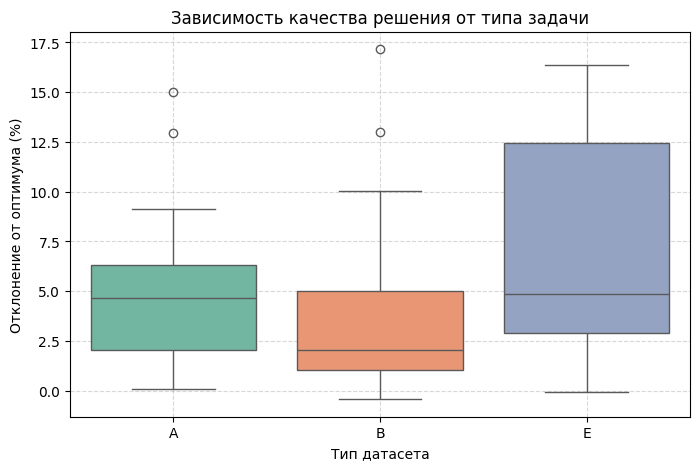

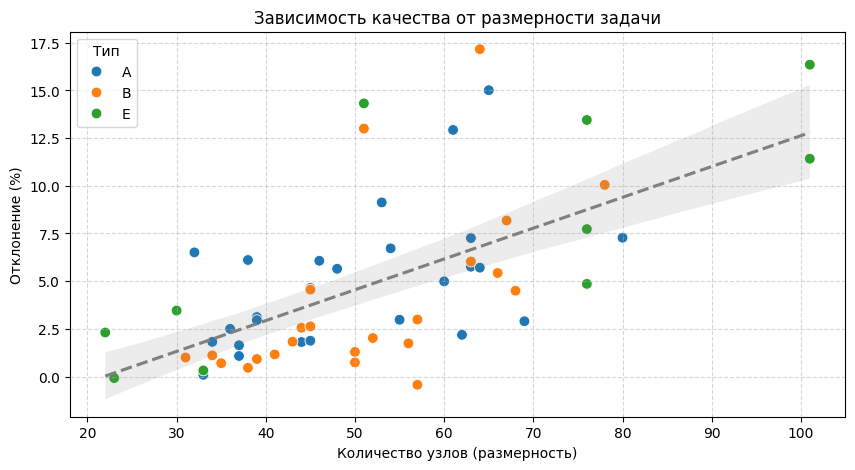

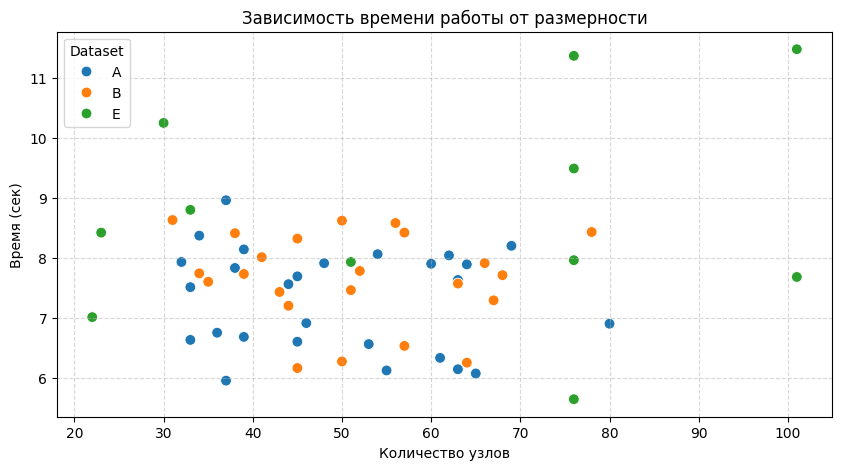

In [10]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

data_str = """Dataset,File,My Cost,Optimal,Deviation,Time,Size
A,A-n32-k5.vrp,835.01,784.0,6.51,7.93,32
A,A-n33-k5.vrp,662.26,661.0,0.19,7.51,33
A,A-n33-k6.vrp,742.69,742.0,0.09,6.63,33
A,A-n34-k5.vrp,792.16,778.0,1.82,8.37,34
A,A-n36-k5.vrp,818.99,799.0,2.50,6.75,36
A,A-n37-k5.vrp,676.21,669.0,1.08,8.96,37
A,A-n37-k6.vrp,964.57,949.0,1.64,5.95,37
A,A-n38-k5.vrp,774.59,730.0,6.11,7.83,38
A,A-n39-k5.vrp,847.62,822.0,3.12,6.68,39
A,A-n39-k6.vrp,855.61,831.0,2.96,8.14,39
A,A-n44-k6.vrp,953.95,937.0,1.81,7.56,44
A,A-n45-k6.vrp,961.78,944.0,1.88,6.60,45
A,A-n45-k7.vrp,1199.33,1146.0,4.65,7.69,45
A,A-n46-k7.vrp,969.49,914.0,6.07,6.91,46
A,A-n48-k7.vrp,1133.59,1073.0,5.65,7.91,48
A,A-n53-k7.vrp,1102.19,1010.0,9.13,6.56,53
A,A-n54-k7.vrp,1245.48,1167.0,6.72,8.06,54
A,A-n55-k9.vrp,1105.00,1073.0,2.98,6.12,55
A,A-n60-k9.vrp,1421.57,1354.0,4.99,7.90,60
A,A-n61-k9.vrp,1167.71,1034.0,12.93,6.33,61
A,A-n62-k8.vrp,1316.16,1288.0,2.19,8.04,62
A,A-n63-k10.vrp,1389.67,1314.0,5.76,7.63,63
A,A-n63-k9.vrp,1733.30,1616.0,7.26,6.14,63
A,A-n64-k9.vrp,1480.99,1401.0,5.71,7.89,64
A,A-n65-k9.vrp,1350.18,1174.0,15.01,6.07,65
A,A-n69-k9.vrp,1192.66,1159.0,2.90,8.20,69
A,A-n80-k10.vrp,1891.30,1763.0,7.28,6.90,80
B,B-n31-k5.vrp,678.71,672.0,1.00,8.63,31
B,B-n34-k5.vrp,796.74,788.0,1.11,7.74,34
B,B-n35-k5.vrp,961.72,955.0,0.70,7.60,35
B,B-n38-k6.vrp,808.70,805.0,0.46,8.41,38
B,B-n39-k5.vrp,554.06,549.0,0.92,7.73,39
B,B-n41-k6.vrp,838.61,829.0,1.16,8.01,41
B,B-n43-k6.vrp,755.58,742.0,1.83,7.43,43
B,B-n44-k7.vrp,932.29,909.0,2.56,7.20,44
B,B-n45-k5.vrp,785.24,751.0,4.56,8.32,45
B,B-n45-k6.vrp,695.80,678.0,2.63,6.16,45
B,B-n50-k7.vrp,750.57,741.0,1.29,8.62,50
B,B-n50-k8.vrp,1321.66,1312.0,0.74,6.27,50
B,B-n51-k7.vrp,1166.16,1032.0,13.00,7.46,51
B,B-n52-k7.vrp,762.09,747.0,2.02,7.78,52
B,B-n56-k7.vrp,719.31,707.0,1.74,8.58,56
B,B-n57-k7.vrp,1148.09,1153.0,-0.43,8.42,57
B,B-n57-k9.vrp,1645.71,1598.0,2.99,6.53,57
B,B-n63-k10.vrp,1586.16,1496.0,6.03,7.57,63
B,B-n64-k9.vrp,1008.78,861.0,17.16,6.25,64
B,B-n66-k9.vrp,1387.48,1316.0,5.43,7.91,66
B,B-n67-k10.vrp,1116.38,1032.0,8.18,7.29,67
B,B-n68-k9.vrp,1329.24,1272.0,4.50,7.71,68
B,B-n78-k10.vrp,1343.77,1221.0,10.05,8.43,78
E,E-n101-k14.vrp,1188.83,1067.0,11.42,7.68,101
E,E-n101-k8.vrp,948.25,815.0,16.35,11.48,101
E,E-n22-k4.vrp,383.65,375.0,2.31,7.01,22
E,E-n23-k3.vrp,568.56,569.0,-0.08,8.42,23
E,E-n30-k3.vrp,552.45,534.0,3.46,10.25,30
E,E-n33-k4.vrp,837.67,835.0,0.32,8.80,33
E,E-n51-k5.vrp,595.62,521.0,14.32,7.93,51
E,E-n76-k10.vrp,941.63,830.0,13.45,7.96,76
E,E-n76-k14.vrp,1099.92,1021.0,7.73,5.64,76
E,E-n76-k7.vrp,714.92,682.0,4.83,11.37,76
E,E-n76-k8.vrp,770.73,735.0,4.86,9.49,76
"""

from io import StringIO
df = pd.read_csv(StringIO(data_str))


# --- АНАЛИЗ 2: Зависимость от РАЗМЕРНОСТИ ---
# Разобьем задачи на группы по размеру
bins = [0, 40, 60, 120]
labels = ['Малые (<40)', 'Средние (40-60)', 'Большие (>60)']
df['SizeGroup'] = pd.cut(df['Size'], bins=bins, labels=labels)

# --- ГРАФИКИ ДЛЯ ПРЕЗЕНТАЦИИ ---

# График 1: Качество по типам (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x='Dataset', y='Deviation', data=df, palette='Set2')
plt.title('Зависимость качества решения от типа задачи')
plt.ylabel('Отклонение от оптимума (%)')
plt.xlabel('Тип датасета')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# График 2: Качество от Размерности (Scatter + Line)
plt.figure(figsize=(10,5))
sns.scatterplot(x='Size', y='Deviation', hue='Dataset', data=df, s=60)
sns.regplot(x='Size', y='Deviation', data=df, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title('Зависимость качества от размерности задачи')
plt.ylabel('Отклонение (%)')
plt.xlabel('Количество узлов (размерность)')
plt.legend(title='Тип')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# График 3: Время от Размерности
plt.figure(figsize=(10,5))
sns.scatterplot(x='Size', y='Time', hue='Dataset', data=df, s=60)
plt.title('Зависимость времени работы от размерности')
plt.ylabel('Время (сек)')
plt.xlabel('Количество узлов')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()